
<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'> Logistic Regression </h2>
</div>

###  Logistic Regression 			

- Logistic regression are S-curve/Sigmoid-Curve	

- Logistic Regression is stastical method to predict binary outcome. The target variable is binary and independent varibles are continous.	

- Independent variables(X-axis) are continues, here depenent variables (Y-axis) are discret 0 or 1, based on threshold level, above that will be treated as 1 below as 0	

- In Linear Regression output values also continues, but in Logistic regression output values are  binary values	


<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>


# Model 7 Supervised Leraning

## Case Study
    Objectives:
            •Fit a model using binary classification using logistic regression.
            •Identify correlated variables and form a less complex model.

## 1.We will use acoustic features to distinguish a male voice from female. 
    - Load the dataset from “voice.csv”,
    - identify the target variable and do a one-hot encoding for the same. 
    - Split the dataset in train-test with 20% of the data kept aside for testing.
    
    [Hint: Refer to LabelEncoder documentation in scikit-learn]

## 1. Import all Librariy

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

acostic_df = pd.read_csv(r"..\Dataset\voice.csv")
acostic_df.head()
acostic_df

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male
5,0.132786,0.079557,0.119090,0.067958,0.209592,0.141634,1.932562,8.308895,0.963181,0.738307,...,0.132786,0.110132,0.017112,0.253968,0.298222,0.007812,2.726562,2.718750,0.125160,male
6,0.150762,0.074463,0.160106,0.092899,0.205718,0.112819,1.530643,5.987498,0.967573,0.762638,...,0.150762,0.105945,0.026230,0.266667,0.479620,0.007812,5.312500,5.304688,0.123992,male
7,0.160514,0.076767,0.144337,0.110532,0.231962,0.121430,1.397156,4.766611,0.959255,0.719858,...,0.160514,0.093052,0.017758,0.144144,0.301339,0.007812,0.539062,0.531250,0.283937,male
8,0.142239,0.078018,0.138587,0.088206,0.208587,0.120381,1.099746,4.070284,0.970723,0.770992,...,0.142239,0.096729,0.017957,0.250000,0.336476,0.007812,2.164062,2.156250,0.148272,male
9,0.134329,0.080350,0.121451,0.075580,0.201957,0.126377,1.190368,4.787310,0.975246,0.804505,...,0.134329,0.105881,0.019300,0.262295,0.340365,0.015625,4.695312,4.679688,0.089920,male


## 2. Data Exploration with Graphs and Visualization


# Shuffling
Now when you visualize the dataset, you can see, that in the labels column, the values are all in descending order. (This doesn’t impact much during training but we’re going to split our dataset soon, so it shall cause a problem)

In [82]:
acostic_df = acostic_df.sample(frac=1).reset_index(drop=True)
acostic_df

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.192281,0.041970,0.197156,0.189689,0.204800,0.015111,3.919928,18.890319,0.824379,0.274805,...,0.192281,0.193415,0.070423,0.270270,0.483023,0.200195,0.795898,0.595703,0.695697,female
1,0.175311,0.068150,0.160749,0.127551,0.241997,0.114446,1.438899,4.568239,0.939701,0.599018,...,0.175311,0.133196,0.047105,0.271186,1.479992,0.023438,21.867188,21.843750,0.074511,male
2,0.141566,0.076678,0.126486,0.100935,0.207994,0.107059,3.578447,23.852829,0.943157,0.657765,...,0.141566,0.120040,0.028219,0.246154,0.093750,0.007812,0.414062,0.406250,0.151709,male
3,0.156854,0.062058,0.138373,0.109774,0.217492,0.107719,2.483267,12.774804,0.933270,0.515668,...,0.156854,0.099983,0.015083,0.140845,0.408842,0.053711,0.776367,0.722656,0.614865,male
4,0.140897,0.073719,0.129847,0.089819,0.198187,0.108368,1.916411,7.175046,0.946765,0.649326,...,0.140897,0.097979,0.023599,0.219178,0.158717,0.007812,0.492188,0.484375,0.301971,male
5,0.178028,0.070548,0.190000,0.127436,0.242821,0.115385,2.149795,9.174200,0.945836,0.637708,...,0.178028,0.116113,0.020101,0.275862,0.983854,0.031250,5.109375,5.078125,0.225199,male
6,0.193306,0.050840,0.216294,0.146104,0.231553,0.085450,2.088317,7.715960,0.889679,0.143810,...,0.193306,0.127126,0.029466,0.275862,1.098558,0.101562,4.820312,4.718750,0.198510,male
7,0.224631,0.034970,0.223060,0.205821,0.249701,0.043881,1.638822,4.749142,0.839121,0.181604,...,0.224631,0.212826,0.050420,0.279070,0.795455,0.023438,4.078125,4.054688,0.112610,female
8,0.141798,0.086852,0.167028,0.044903,0.217365,0.172462,1.027733,3.588617,0.965640,0.758995,...,0.141798,0.181397,0.084211,0.258065,0.445747,0.031250,0.929688,0.898438,0.386701,female
9,0.191024,0.059709,0.212926,0.128296,0.244437,0.116141,1.949876,7.061099,0.889087,0.302066,...,0.191024,0.130177,0.048096,0.277457,1.398607,0.023438,5.484375,5.460938,0.191805,male


In [83]:
Y = acostic_df["label"]
Y.head()


0    female
1      male
2      male
3      male
4      male
Name: label, dtype: object

### LabelEncoder can be used to normalize labels.

In [84]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
#Or we can use fit_transform instead of separate fit and transform
#le.fit_transform(Y)
le.fit(Y)
#le.classes_ provides distinct labels
le.classes_
# 0 -->female,  1--->male

array(['female', 'male'], dtype=object)

In [85]:
#This converts data from female -->0 aand Male to 1  means here its normalized  in 0,1
Y_le = le.transform(Y)
Y_le

array([0, 1, 1, ..., 1, 1, 1])

In [87]:
#Another method
#acostic_df["label"].replace(to_replace = dict(female = 1, male = 0), inplace = True)
# OR
#acostic_df['label'] = data['label'].replace(['female', 'male'],[1,0])

## 3. Building Machine Learning Logistic Models

In [88]:
from sklearn.model_selection import train_test_split

X =  acostic_df.iloc[: , 0:20]

#Converted field used as Y : Y_le
train_X, test_X, train_Y, test_Y = train_test_split(X,Y_le, test_size = 0.20, random_state = 10)

In [89]:
print(train_X.head())
print(train_Y)
print(test_X.head())
print(test_Y)

      meanfreq        sd    median       Q25       Q75       IQR      skew  \
2953  0.230144  0.033577  0.231368  0.222526  0.246105  0.023579  3.413691   
423   0.173038  0.063109  0.165428  0.141823  0.224729  0.082906  2.828893   
1150  0.211290  0.039754  0.211048  0.191481  0.236206  0.044725  1.950154   
2433  0.225222  0.035246  0.221417  0.208962  0.250939  0.041977  2.535751   
169   0.168136  0.060432  0.170222  0.141977  0.202609  0.060632  4.847925   

           kurt    sp.ent       sfm      mode  centroid   meanfun    minfun  \
2953  17.897104  0.809968  0.174234  0.229158  0.230144  0.201065  0.047059   
423   14.763652  0.933887  0.568803  0.163701  0.173038  0.146290  0.020790   
1150   7.001164  0.865188  0.267505  0.192879  0.211290  0.149306  0.047105   
2433  11.503406  0.845708  0.192119  0.213114  0.225222  0.176216  0.047384   
169   51.204956  0.923530  0.541465  0.059126  0.168136  0.143245  0.022173   

        maxfun   meandom    mindom    maxdom   dfrange  

## 2.Fit a logistic regression model and measure the accuracy on the test set.
    [Hint:Refer to Linear Models section in scikit-learn]

In [90]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()

log_reg.fit(train_X, train_Y)
pred_Y = log_reg.predict(test_X)
pred_Y

C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


array([0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,

## 4. Model Evaluation

In [91]:
##Accuracy score,
from sklearn import metrics
metrics.accuracy_score(test_Y, pred_Y)
#Here accuracy score is 92%

0.8927444794952681

#### 4.1.Compute the correlation matrix that describes the dependence between all predictors and identify the predictors that are highly correlated.  
    Plot the correlation matrix using seaborn heatmap.
    [Hint: Explore dataframe methods to identify appropriate method

          meanfreq        sd    median       Q25       Q75       IQR  \
meanfreq  1.000000 -0.739039  0.925445  0.911416  0.740997 -0.627605   
sd       -0.739039  1.000000 -0.562603 -0.846931 -0.161076  0.874660   
median    0.925445 -0.562603  1.000000  0.774922  0.731849 -0.477352   
Q25       0.911416 -0.846931  0.774922  1.000000  0.477140 -0.874189   
Q75       0.740997 -0.161076  0.731849  0.477140  1.000000  0.009636   
IQR      -0.627605  0.874660 -0.477352 -0.874189  0.009636  1.000000   
skew     -0.322327  0.314597 -0.257407 -0.319475 -0.206339  0.249497   
kurt     -0.316036  0.346241 -0.243382 -0.350182 -0.148881  0.316185   
sp.ent   -0.601203  0.716620 -0.502005 -0.648126 -0.174905  0.640813   
sfm      -0.784332  0.838086 -0.661690 -0.766875 -0.378198  0.663601   
mode      0.687715 -0.529150  0.677433  0.591277  0.486857 -0.403764   
centroid  1.000000 -0.739039  0.925445  0.911416  0.740997 -0.627605   
meanfun   0.460844 -0.466281  0.414909  0.545035  0.155091 -0.53

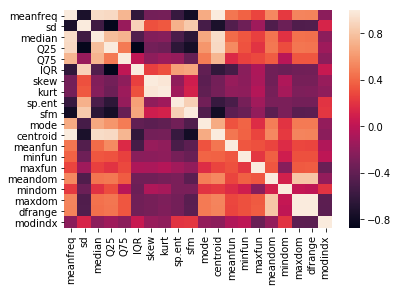

In [92]:
import seaborn as sn
correlation = X.corr()
print(correlation)
sn.heatmap(correlation)
plt.show()

In [93]:
X.columns

Index(['meanfreq', 'sd', 'median', 'Q25', 'Q75', 'IQR', 'skew', 'kurt',
       'sp.ent', 'sfm', 'mode', 'centroid', 'meanfun', 'minfun', 'maxfun',
       'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx'],
      dtype='object')

In [94]:
"""  Below are selected fields

['meanfreq', 'Q25', 'Q75',  'skew', 'kurt',
       'sp.ent', 'mode',  'meanfun', 'minfun', 'maxfun',
       'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx'],
       
       
Below are excludes fields: these have high -ve or +ve correlation between each other
'meanfreq'  -->  'sd', 'median', 'IQR', 'sfm', 'centroid',
"""

"  Below are selected fields\n\n['meanfreq', 'Q25', 'Q75',  'skew', 'kurt',\n       'sp.ent', 'mode',  'meanfun', 'minfun', 'maxfun',\n       'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx'],\n       \n       \nBelow are excludes fields: these have high -ve or +ve correlation between each other\n'meanfreq'  -->  'sd', 'median', 'IQR', 'sfm', 'centroid',\n"

### 4.2 Based on correlation remove those predictors that are correlated and fit a logistic regression model again
    and compare the accuracy with that of previous model.
        [Hint:Identify correlated variable pairs and remove one among them]


In [95]:
featue_field_X = X.loc[:, ['meanfreq', 'Q25', 'Q75',  'skew', 'kurt','sp.ent', 'mode',  'meanfun', 'minfun', 'maxfun',
       'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx']]

In [96]:

train_fet_X, test_fet_X, train_fet_Y, test_fet_Y = train_test_split(featue_field_X,Y_le, test_size = 0.20, random_state = 10)
print(test_fet_X)

      meanfreq       Q25       Q75       skew         kurt    sp.ent  \
2513  0.220354  0.204214  0.237342   2.318320     8.617342  0.830597   
965   0.230900  0.213745  0.252922   2.103972     7.459465  0.819037   
822   0.120183  0.043277  0.193879   1.218909     4.438278  0.964463   
980   0.193123  0.179206  0.240127   3.114001    21.220924  0.921173   
1427  0.180948  0.132603  0.225205   1.562671     5.363529  0.907099   
924   0.197889  0.136616  0.249970   1.421407     4.896696  0.913793   
1637  0.207089  0.177123  0.233414   1.594182     5.237594  0.888897   
2964  0.177195  0.137990  0.246507   2.270383     9.041124  0.925782   
1891  0.174052  0.145852  0.209235   2.480105     9.979111  0.925644   
236   0.165113  0.117278  0.227391   2.806798    13.195741  0.910558   
2039  0.114828  0.044042  0.179905   1.021112     3.811971  0.969638   
2200  0.193138  0.176582  0.206287   2.815214    12.030305  0.855316   
970   0.203549  0.150145  0.254130   1.440084     4.637305  0.89

In [97]:

log_reg_fet = LogisticRegression()

log_reg_fet.fit(train_fet_X, train_fet_Y)
pred_Y_fet = log_reg_fet.predict(test_fet_X)
pred_Y_fet

C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


array([0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,

## 5. Model Evaluation
### 5.1 Model Evaluation -Accuracy Score

In [98]:
##Accuracy score, after considering selected fields in feature fields

metrics.accuracy_score(test_fet_Y, pred_Y_fet)
#Here accuracy score is  91% which is not better than previos method 92%
#So considering selected fields by seeing heatmap, provides good model in some cases, here its not better

0.8848580441640379

### 5.2. Model Evaluation -Confusion Matrix

In [99]:
# confusion_matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(test_Y, pred_Y)

array([[267,  59],
       [  9, 299]], dtype=int64)

### 5.3. Model Evaluation - classification_report  

In [100]:
# classification_report
from sklearn.metrics import classification_report

#classification_report(test_Y, pred_Y, target_names= ["Male","Female"])

print(classification_report(test_Y, pred_Y, target_names= ["Male","Female"]))



              precision    recall  f1-score   support

        Male       0.97      0.82      0.89       326
      Female       0.84      0.97      0.90       308

   micro avg       0.89      0.89      0.89       634
   macro avg       0.90      0.89      0.89       634
weighted avg       0.90      0.89      0.89       634



In [101]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('Accuracy: {:.2f}'.format(accuracy_score(test_Y, pred_Y)))
print('Precision: {:.2f}'.format(precision_score(test_Y, pred_Y)))
print('Recall: {:.2f}'.format(recall_score(test_Y, pred_Y)))
print('F1: {:.2f}'.format(f1_score(test_Y, pred_Y)))

Accuracy: 0.89
Precision: 0.84
Recall: 0.97
F1: 0.90


### 5.4. Model Evaluation - ROC AUC  

[0.16117214 0.14884128 0.72151449 0.22806389 0.70128188]
Area under curve 0.9362401402278703


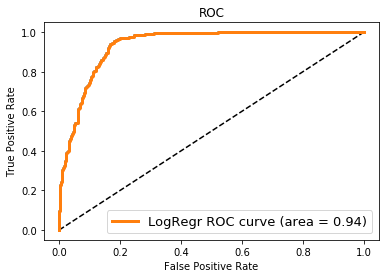

In [102]:
#ROC Curve with AUC
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

#Predictor_score
y_pred_prob = log_reg_fet.predict_proba(test_fet_X)[:,1]
print(y_pred_prob[0:5])


# ROC curve
fpr, tpr, thresholds = roc_curve(test_fet_Y, y_pred_prob)
#print(fpr)
#print(tpr)
#print(thresholds)
roc_auc_lr = auc(fpr, tpr)
print("Area under curve %s" %roc_auc_lr)

# Plot ROC curve
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)  # X axis false +ve rate, Y axis True +ve rate

# Or with AUC
plt.plot(fpr, tpr, lw=3, label='LogRegr ROC curve (area = {:0.2f})'.format(roc_auc_lr))

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', fontsize=13)
plt.title('ROC')
plt.show()
#AUC near to 1 , so looks good